<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_5_Ensemble/18_5_1_Trees_Data_and_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Trees: The Foundation of Ensembles

**Author:** Brad Sheese

---

## Introduction

In 18_1_5, we were introduced to decision trees in the context of regression (predicting house prices). This notebook revisits trees for **classification** — predicting whether a breast tumor is malignant or benign.

The core mechanics are the same: the tree asks yes/no questions to split the data. But the evaluation metrics are different. In regression, we used R² and MSE. In classification, we need precision, recall, F1, and the ROC curve — especially in a medical context where false negatives (missing a cancer) are far more costly than false positives.

### Learning Objectives
By the end of this notebook, you will be able to:
1. Load and explore the Wisconsin Breast Cancer dataset.
2. Implement a Decision Tree classifier using scikit-learn.
3. Visualize the model's decision-making process with a tree diagram.
4. Evaluate the impact of tree depth on model accuracy and overfitting.
5. Interpret the confusion matrix, precision, recall, and F1-score in a medical context.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc

sns.set_context("talk")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Preparation: Wisconsin Breast Cancer Dataset

Measurements from digitized images of fine needle aspirates (FNA) of breast masses. Features describe characteristics of cell nuclei.

- **569 samples**, **30 features** (mean, SE, and "worst" for 10 cell nucleus characteristics)
- **Target**: Malignant (1) or Benign (0)
- **Class distribution**: ~63% benign, ~37% malignant

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame

print(f"Dataset shape: {df.shape}")
print(f"\nTarget distribution:")
print(df['target'].value_counts(normalize=True))
print(f"\nTarget names: {dict(enumerate(data.target_names))}")

Dataset shape: (569, 31)

Target distribution:
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64

Target names: {0: np.str_('malignant'), 1: np.str_('benign')}


### Visualizing Feature Distributions

Trees don't care about skew or scaling — unlike linear regression, we don't need to transform features. But let's still look at the data.

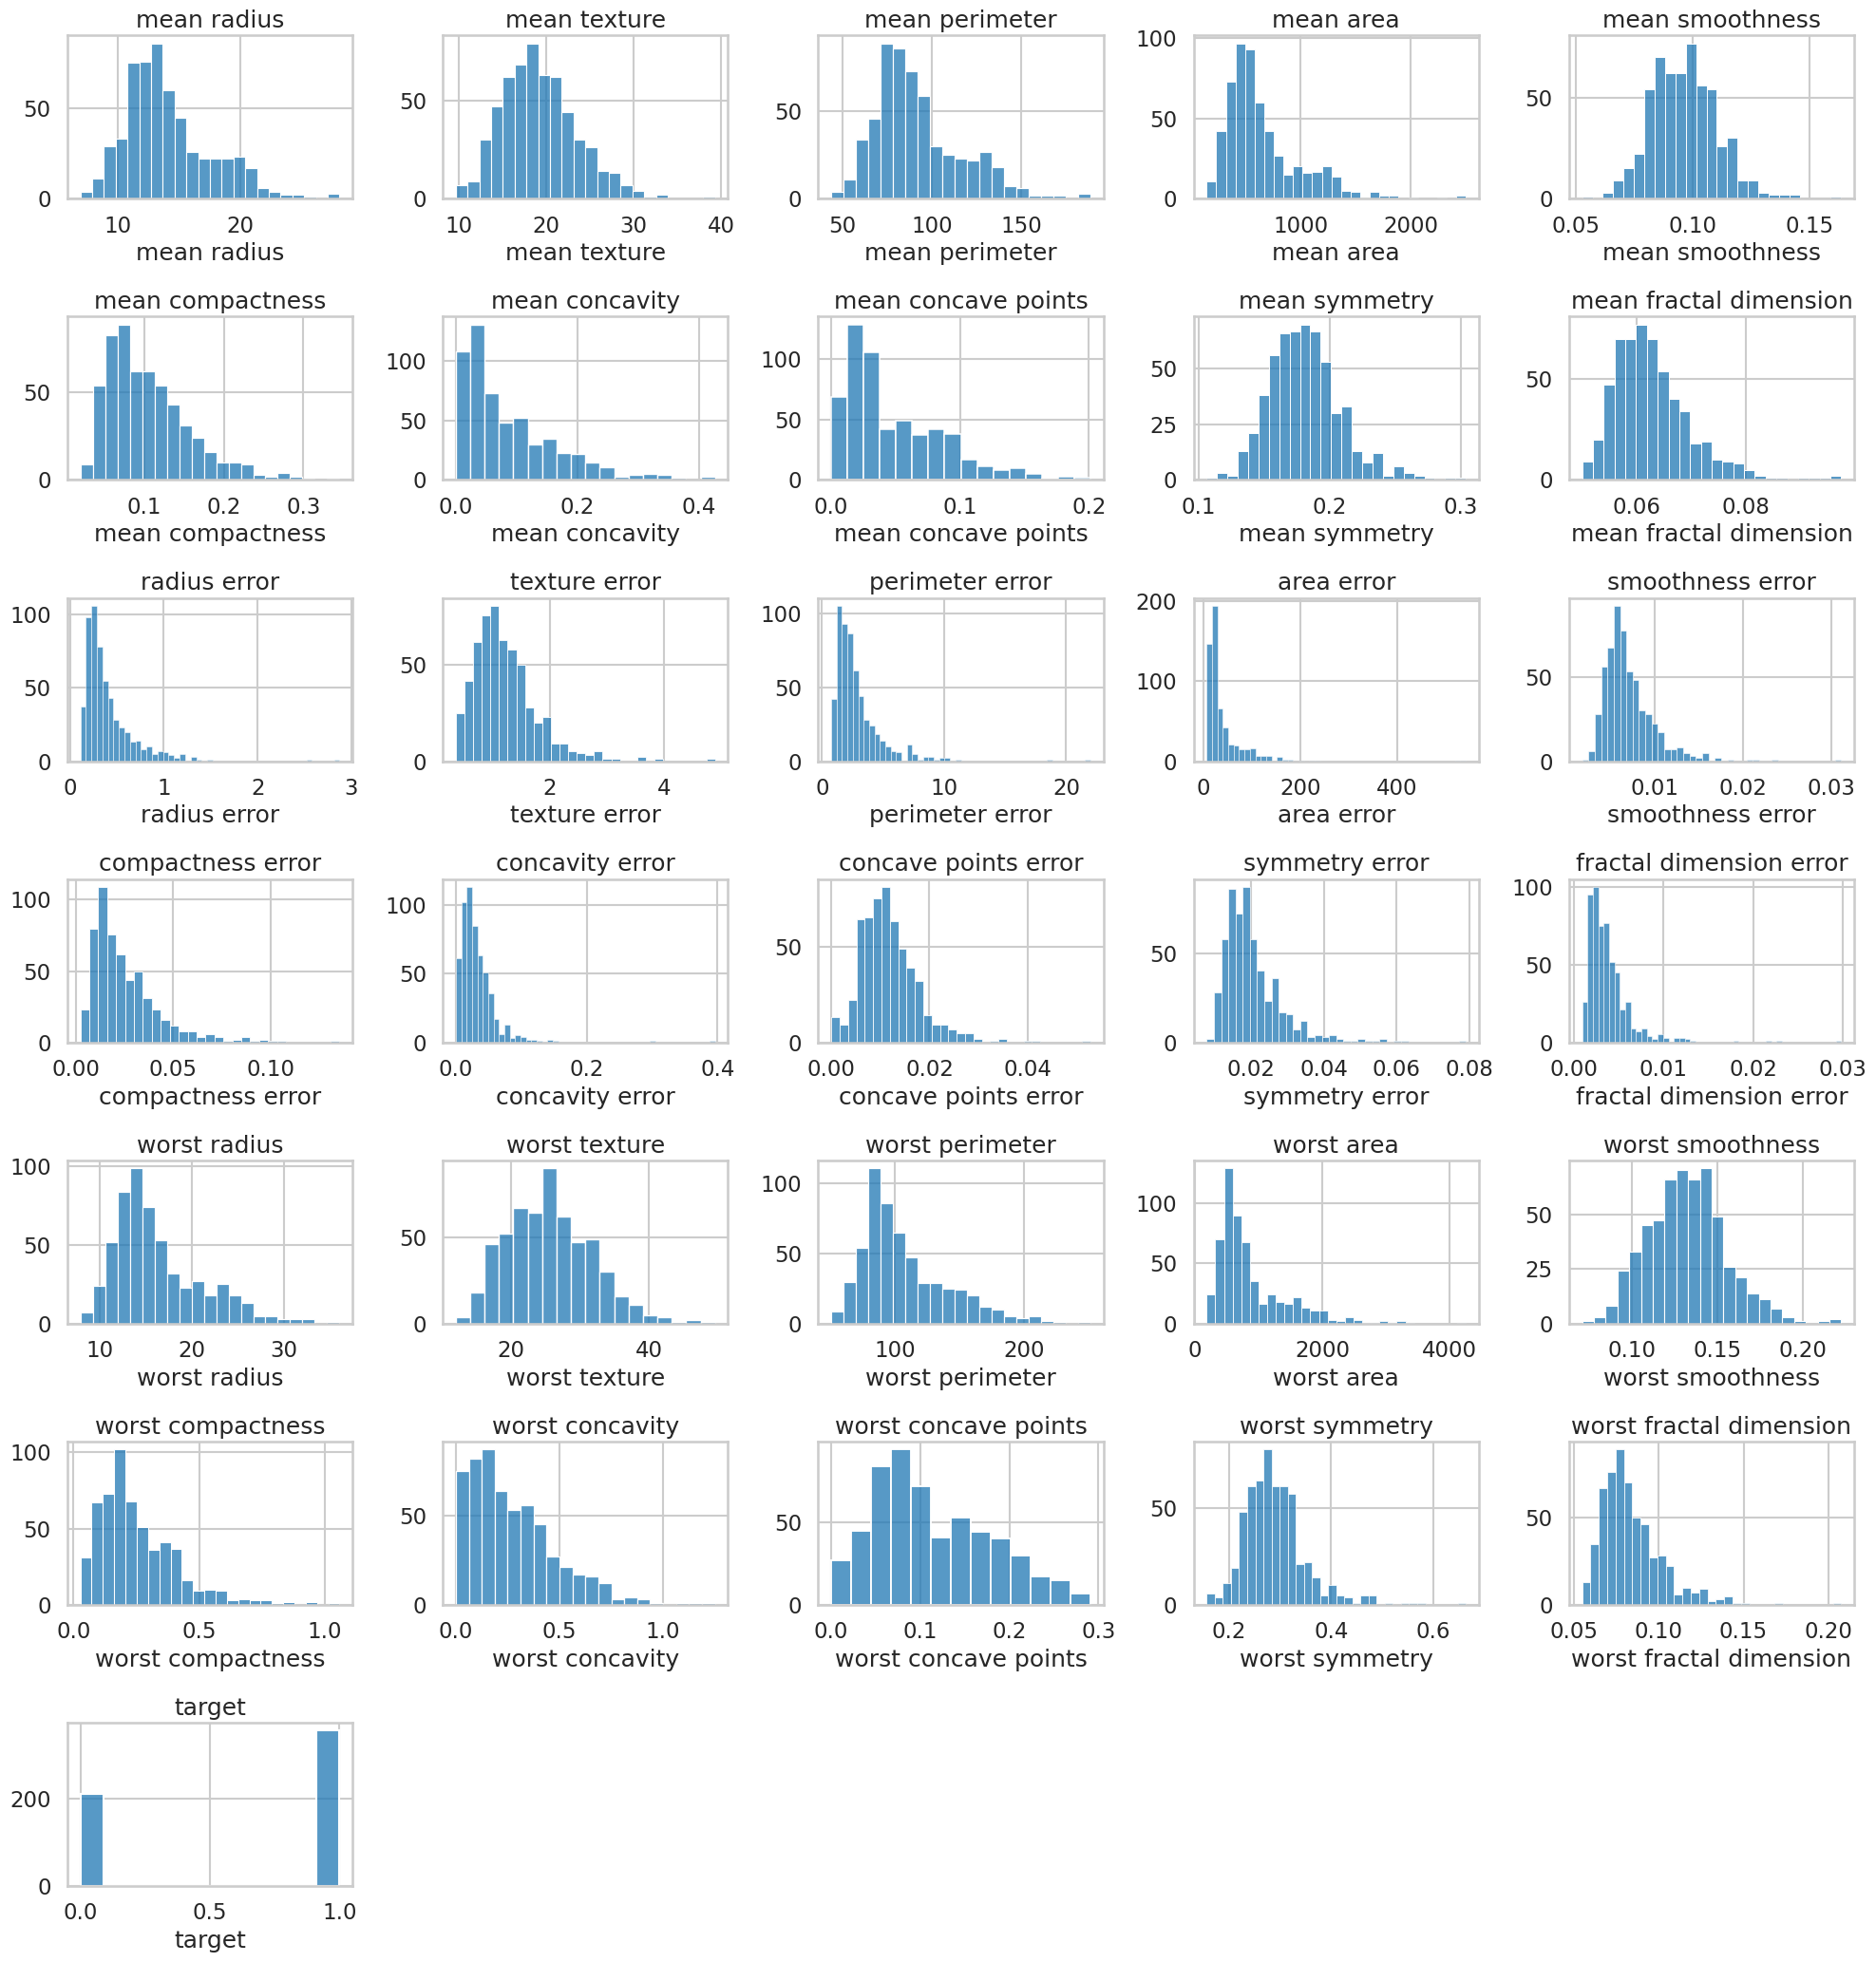

In [3]:
n_cols = 5
n_features = len(df.columns)
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.histplot(df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Visualizing a Split

Let's look at `mean concave points` — one of the strongest differentiators between malignant and benign tumors.

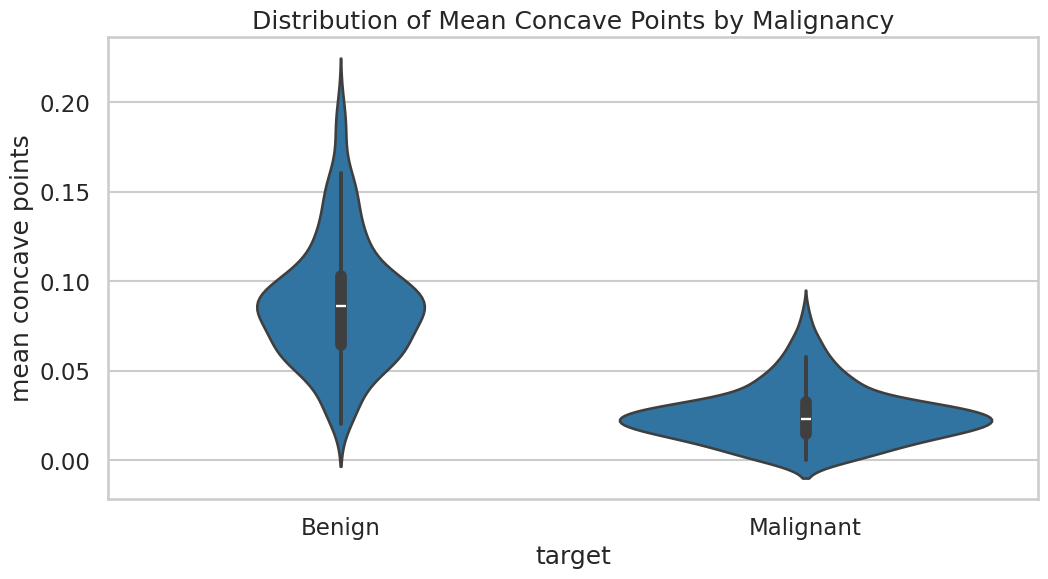

In [4]:
sns.violinplot(x='target', y='mean concave points', data=df)
plt.title("Distribution of Mean Concave Points by Malignancy")
plt.xticks([0, 1], ['Benign', 'Malignant'])
plt.show()

The clear separation here means the tree will likely use this feature near the top. Let's see all features at once.

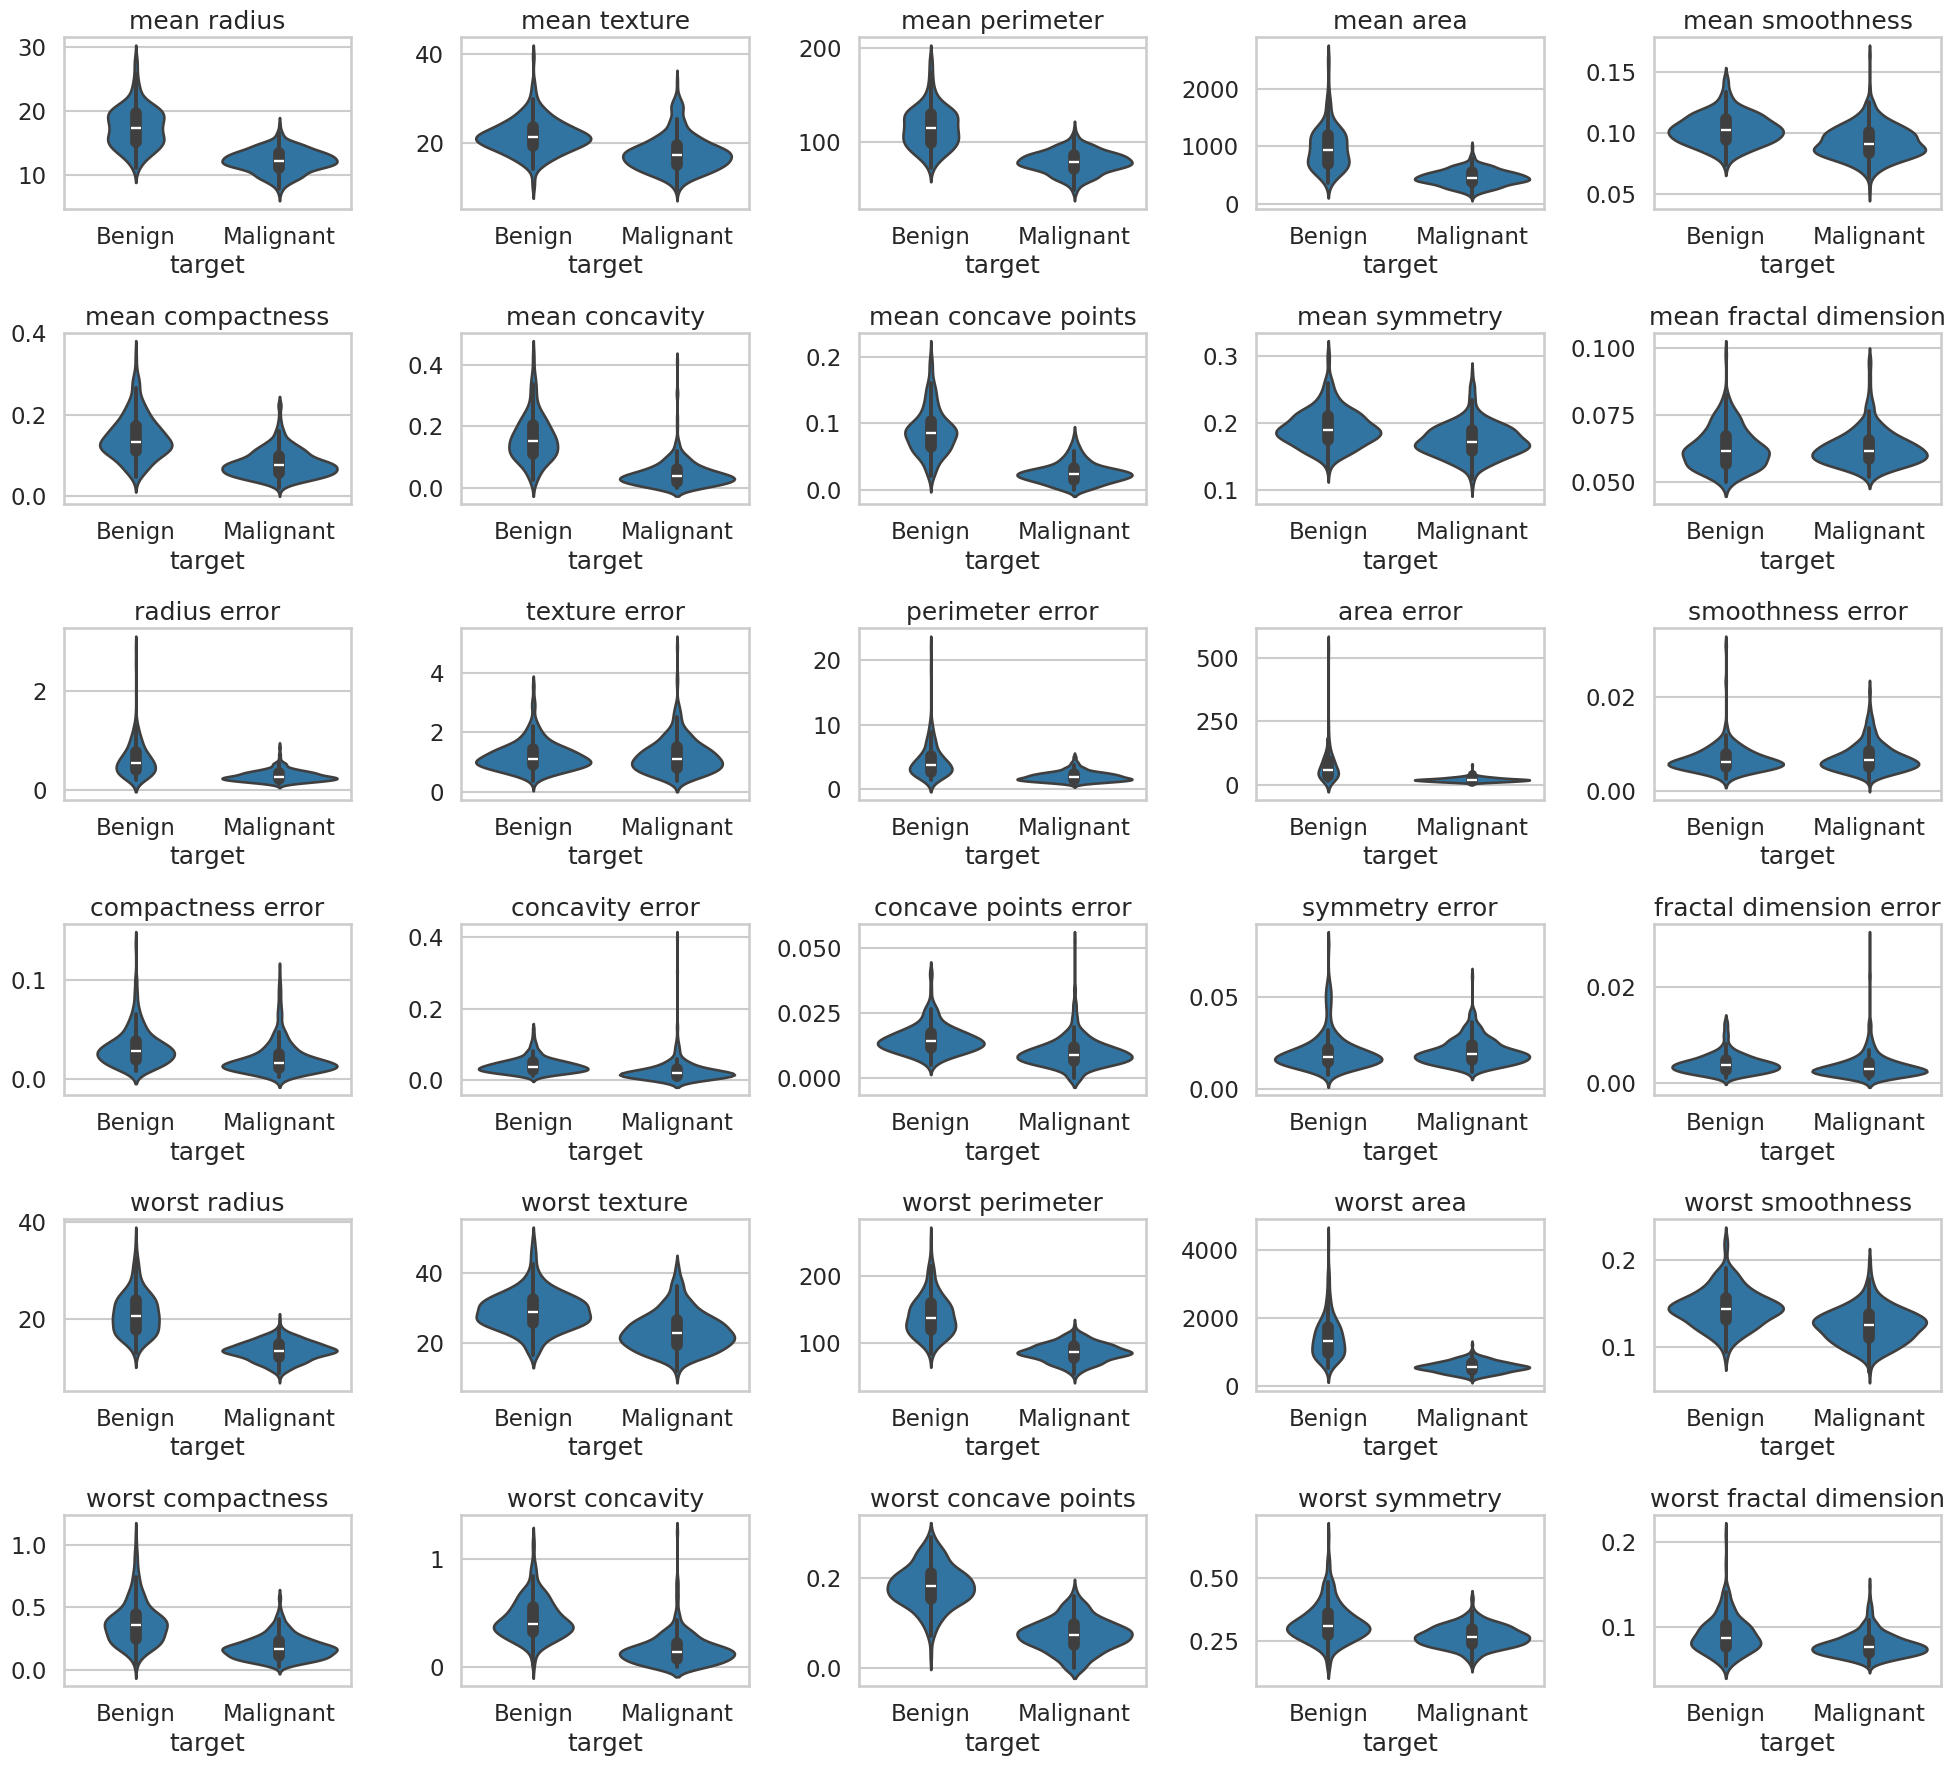

In [5]:
n_cols = 5
n_features = len(df.columns[:-1])
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(df.columns[:-1]):
    sns.violinplot(x='target', y=col, data=df, ax=axes[i])
    axes[i].set_title(f"{col}")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Benign', 'Malignant'])
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Train/Test Split

In [6]:
X = df.drop('target', axis=1)
y = df['target']

# Flip target: 1=malignant, 0=benign (matching original UCI encoding)
y = 1 - y

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
print(f"Test set class ratio: {y_test.mean():.1%} malignant, {(1-y_test.mean()):.1%} benign")

Training set size: 398
Testing set size: 171
Test set class ratio: 62.6% malignant, 37.4% benign


---
## 2. A Single Decision Tree

We'll start with a tree limited to `max_depth=3` to keep it interpretable. Recall from 18_1_5: each node asks a yes/no question, splitting the data until reaching a leaf where the prediction is the majority class.

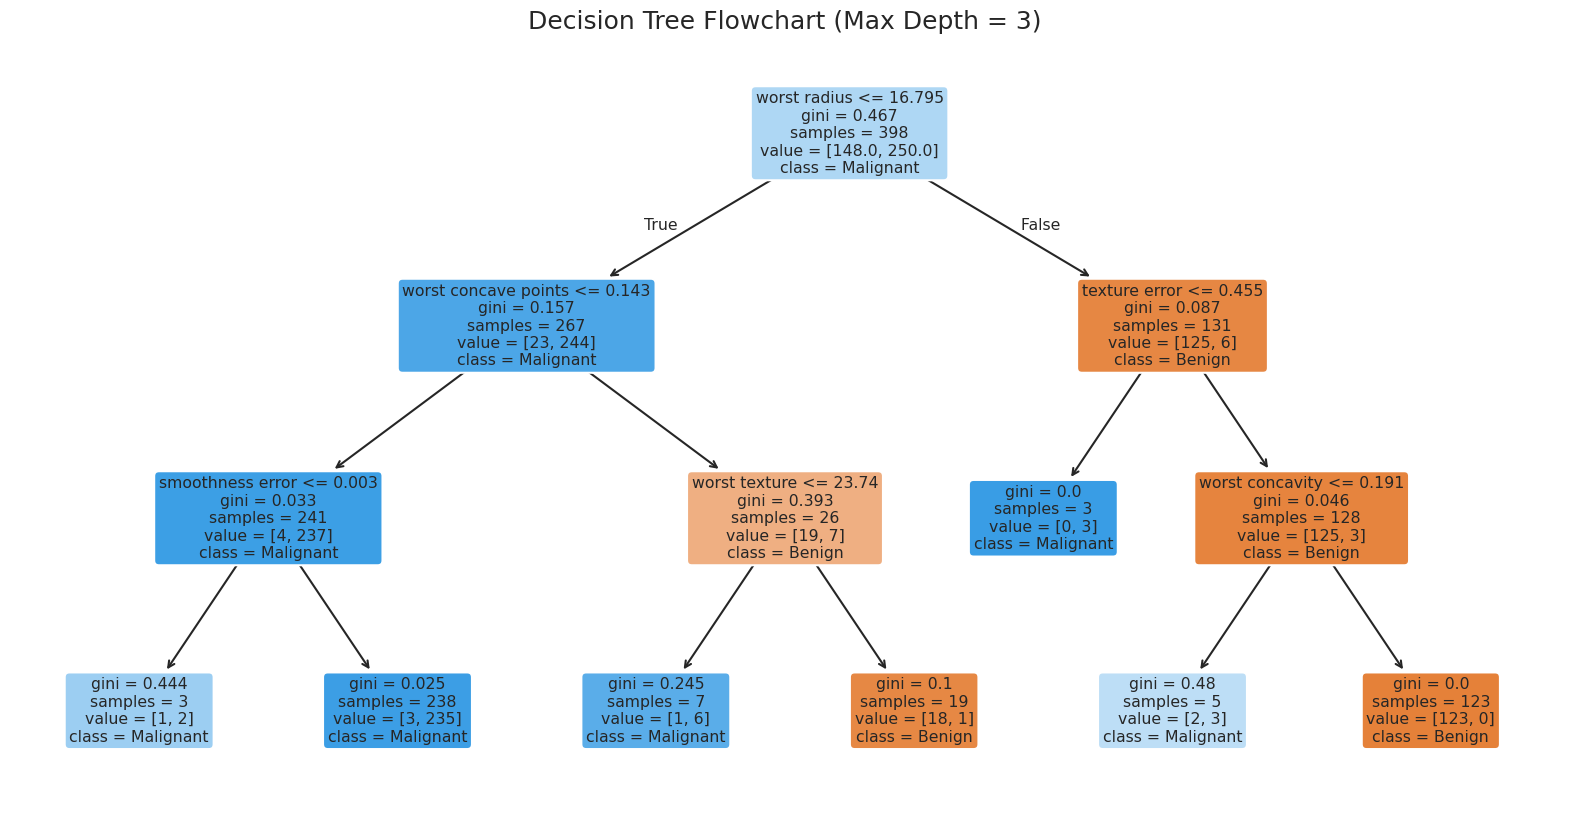

In [7]:
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(clf,
          feature_names=data.feature_names,
          class_names=['Benign', 'Malignant'],
          filled=True,
          rounded=True)
plt.title("Decision Tree Flowchart (Max Depth = 3)")
plt.show()

### How to Read the Tree

Each node shows:
1. **Condition**: The question (e.g., `mean concave points <= 0.051`). True → left, False → right.
2. **Gini**: Impurity measure. 0.0 = pure (one class), 0.5 = maximally mixed.
3. **Samples**: Number of patients in this node.
4. **Value**: `[benign count, malignant count]`.
5. **Class**: The predicted class (majority vote).
6. **Color**: Orange = benign, Blue = malignant. Darker = purer.

---
## 3. The Overfitting Problem: Depth vs. Generalization

As we saw in 18_1_5, an unconstrained tree will memorize the training data. Let's verify this with our classification data.

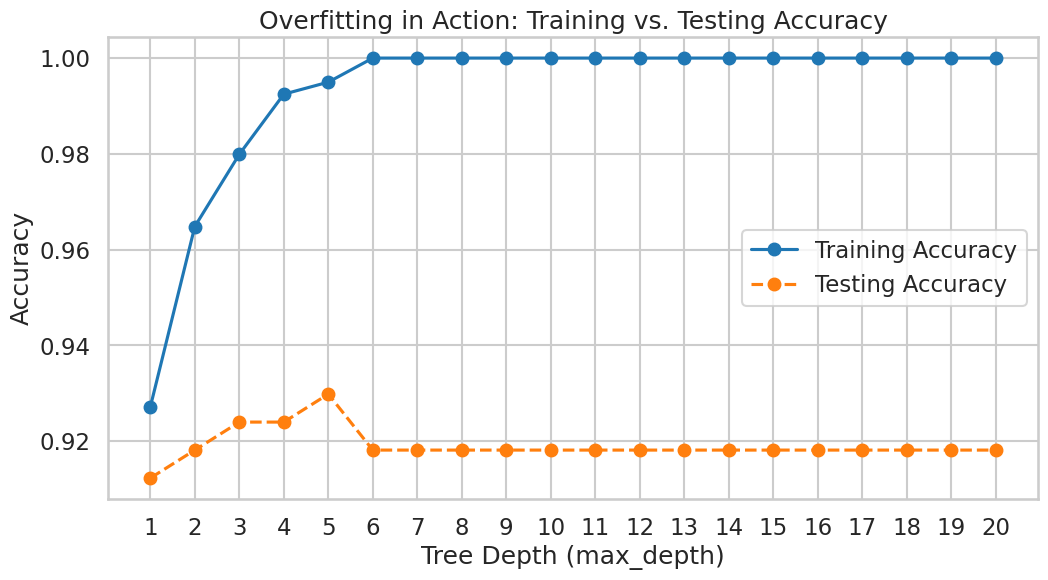

Best Testing Accuracy occurs at Depth: 5
Training Accuracy at Depth 5: 0.995
Testing Accuracy at Depth 5: 0.930


In [8]:
depths = range(1, 21)
train_scores = []
test_scores = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, tree.predict(X_train)))
    test_scores.append(accuracy_score(y_test, tree.predict(X_test)))

plt.figure(figsize=(12, 6))
plt.plot(depths, train_scores, label='Training Accuracy', marker='o', linestyle='-')
plt.plot(depths, test_scores, label='Testing Accuracy', marker='o', linestyle='--')

plt.xlabel('Tree Depth (max_depth)')
plt.ylabel('Accuracy')
plt.title('Overfitting in Action: Training vs. Testing Accuracy')
plt.legend()
plt.grid(True)
plt.xticks(depths)
plt.show()

best_depth = depths[np.argmax(test_scores)]
print(f"Best Testing Accuracy occurs at Depth: {best_depth}")
print(f"Training Accuracy at Depth {best_depth}: {train_scores[best_depth-1]:.3f}")
print(f"Testing Accuracy at Depth {best_depth}: {test_scores[best_depth-1]:.3f}")

### Analyzing the Complexity Curve

- **Training accuracy** (solid line) climbs to 1.0 — the tree memorizes the training data.
- **Testing accuracy** (dashed line) peaks then plateaus or drops — the model stops generalizing.
- The **gap** between the lines is the overfitting penalty.

This is the same bias-variance pattern we saw in 18_1_5 with the Ames data, now expressed through tree depth in a classification context.

---
## 4. Beyond Accuracy: Classification Metrics

In a medical diagnosis context, accuracy alone is dangerous. Let's evaluate our best-depth tree using the full suite of metrics we learned in 18_1_1 and 18_1_2.

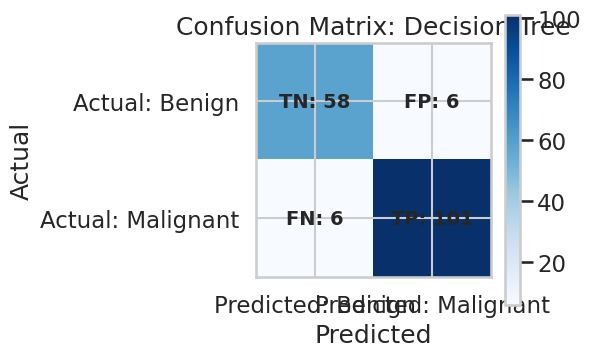


--- Medical Interpretation ---
False Negatives (missed cancers): 6
False Positives (unnecessary biopsies): 6

In a real clinical setting, each false negative represents a cancer that goes undiagnosed.
Each false positive represents a patient who undergoes an unnecessary biopsy.

--- Classification Report ---
               precision    recall  f1-score   support

   Benign (0)       0.91      0.91      0.91        64
Malignant (1)       0.94      0.94      0.94       107

     accuracy                           0.93       171
    macro avg       0.93      0.93      0.93       171
 weighted avg       0.93      0.93      0.93       171



In [9]:
best_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
best_tree.fit(X_train, y_train)
y_pred = best_tree.predict(X_test)
y_proba = best_tree.predict_proba(X_test)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted: Benign', 'Predicted: Malignant'])
ax.set_yticklabels(['Actual: Benign', 'Actual: Malignant'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix: Decision Tree')

labels = [[f'TN: {tn}', f'FP: {fp}'], [f'FN: {fn}', f'TP: {tp}']]
for i in range(2):
    for j in range(2):
        ax.text(j, i, labels[i][j], ha='center', va='center', fontsize=14, fontweight='bold')

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

print(f"\n--- Medical Interpretation ---")
print(f"False Negatives (missed cancers): {fn}")
print(f"False Positives (unnecessary biopsies): {fp}")
print(f"\nIn a real clinical setting, each false negative represents a cancer that goes undiagnosed.")
print(f"Each false positive represents a patient who undergoes an unnecessary biopsy.")
print(f"\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malignant (1)']))

### ROC Curve and AUC

Let's also look at the ROC curve, which shows the trade-off between true positive rate (recall) and false positive rate across all possible thresholds.

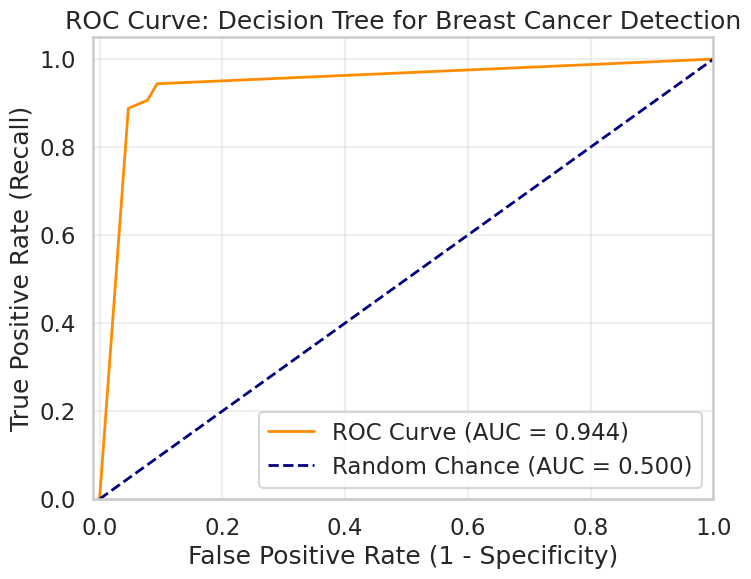

AUC = 0.944
Interpretation: If you randomly pick one malignant and one benign tumor,
the model correctly ranks the malignant one as higher-risk 94.4% of the time.


In [10]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance (AUC = 0.500)')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve: Decision Tree for Breast Cancer Detection')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC = {roc_auc:.3f}")
print(f"Interpretation: If you randomly pick one malignant and one benign tumor,")
print(f"the model correctly ranks the malignant one as higher-risk {roc_auc*100:.1f}% of the time.")

---
## 5. Robust Evaluation: K-Fold Cross-Validation

A single train/test split can be misleading. Let's use 10-fold CV for a more reliable estimate.

In [11]:
from sklearn.model_selection import cross_val_score, KFold

robust_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
kf = KFold(n_splits=10, shuffle=True, random_state=42)

cv_scores = cross_val_score(robust_clf, X, y, cv=kf, scoring='accuracy')

print(f"Cross-Validation Scores (10 Folds):\n{cv_scores}")
print("-" * 30)
print(f"Mean Accuracy: {cv_scores.mean():.3f}")
print(f"Standard Deviation: {cv_scores.std():.3f}")

print(f"\nValidation with k-folds shows consistent performance.")
print(f"Notice there is variation: one fold got {cv_scores.min():.0%} while another got {cv_scores.max():.0%}.")
print(f"\nIf this model were used clinically at {cv_scores.mean():.0%} accuracy,")
print(f"we'd make an incorrect diagnosis in about 1 in {int(1/(1-cv_scores.mean()))} patients.")

Cross-Validation Scores (10 Folds):
[0.94736842 0.94736842 0.94736842 0.92982456 0.9122807  0.89473684
 0.94736842 0.98245614 0.96491228 0.96428571]
------------------------------
Mean Accuracy: 0.944
Standard Deviation: 0.025

Validation with k-folds shows consistent performance.
Notice there is variation: one fold got 89% while another got 98%.

If this model were used clinically at 94% accuracy,
we'd make an incorrect diagnosis in about 1 in 17 patients.


### Your Turn

1. The confusion matrix above shows the false negative count. If this model were used to screen 10,000 patients, approximately how many cancers would be missed? (Use the recall for the malignant class from the report.)
2. The ROC AUC is shown in the plot above. What does this mean in practical terms for a doctor using this model?
3. The CV standard deviation is printed in the output above. Is this model stable enough for clinical use? What would you do to improve it?

## Conclusion

A single decision tree is interpretable but unstable. The depth experiment showed that training accuracy reaches 1.0 while test accuracy plateaus — classic overfitting. The classification metrics revealed that even our "best" tree misses some cancers (false negatives), which is unacceptable in a clinical setting.

In the next notebook, we'll solve this instability problem by combining many trees into an ensemble: **bagging and random forests**.